In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

# --- 1. FETCH & CLEAN RAW DATA ---
print("Fetching Data...")
tickers = {
    'Nifty': '^NSEI',
    'USD_INR': 'INR=X',
    'Crude_Oil': 'CL=F',
    'Gold': 'GC=F',
    'US_10Y': '^TNX'
}

data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']
data.columns = list(tickers.keys())

# CRITICAL FIX: Forward-fill missing days (like Indian holidays vs US holidays)
# We never drop rows here, or we break the timeline!
data.ffill(inplace=True)

# --- 2. FEATURE ENGINEERING ENGINE ---
def engineer_macro_features(df, column_name):
    """Generates Trend, Volatility, and Shock metrics for a given column"""

    # A. Momentum (5-day return)
    # Note: For Yields (US_10Y), we use absolute difference, not % change
    if column_name == 'US_10Y':
        df[f'{column_name}_Mom_5d'] = df[column_name].diff(5)
    else:
        df[f'{column_name}_Mom_5d'] = df[column_name].pct_change(5)

    # B. Volatility (20-day rolling standard deviation of daily returns)
    daily_ret = df[column_name].pct_change()
    df[f'{column_name}_Vol_20d'] = daily_ret.rolling(window=20).std()

    # C. Z-Score (50-day Statistical Shock)
    rolling_mean = df[column_name].rolling(window=50).mean()
    rolling_std = df[column_name].rolling(window=50).std()
    df[f'{column_name}_ZScore_50d'] = (df[column_name] - rolling_mean) / rolling_std

    return df

# --- 3. APPLY TO OUR MACRO INDICATORS ---
macro_variables = ['USD_INR', 'Crude_Oil', 'Gold', 'US_10Y']

for macro in macro_variables:
    data = engineer_macro_features(data, macro)

# Drop the first 50 days where the moving averages were calculating (NaNs)
data.dropna(inplace=True)

print("\nFeature Engineering Complete!")
print(f"Total columns for the AI to analyze: {len(data.columns)}")
print("Sample of our new Gold features:")
print(data[['Gold', 'Gold_Mom_5d', 'Gold_Vol_20d', 'Gold_ZScore_50d']].tail())

Fetching Data...


/tmp/ipykernel_316/2365850559.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']



Feature Engineering Complete!
Total columns for the AI to analyze: 17
Sample of our new Gold features:
                    Gold  Gold_Mom_5d  Gold_Vol_20d  Gold_ZScore_50d
Date                                                                
2026-03-16  23408.800781    -0.025772      0.010583        -2.659895
2026-03-17  23581.150391    -0.028046      0.010834        -2.252151
2026-03-18  23777.800781    -0.003731      0.011063        -1.876441
2026-03-19  23002.150391    -0.026947      0.012613        -2.654408
2026-03-20  23114.500000    -0.001581      0.012625        -2.319622


In [6]:
# --- 4. DEFINING THE TARGET (y) ---
print("Engineering the Target Variable...")

# Calculate the actual future 5-day return
# .shift(-5) pulls the price from 5 days in the future to today's row
lookahead = 5
data['Future_5d_Ret'] = data['Nifty'].pct_change(lookahead).shift(-lookahead)

# We don't care about direction (Up or Down), we only care about MAGNITUDE.
data['Future_Absolute_Move'] = data['Future_5d_Ret'].abs()

# Define what constitutes an "Extreme Move"
# We will set the threshold at the 75th percentile of all historical 5-day moves.
# Anything above this is considered High Volatility.
volatility_threshold = data['Future_Absolute_Move'].quantile(0.75)

# Create the Binary Target: 1 if Extreme Volatility, 0 if Normal/Chop
data['Target_High_Vol'] = np.where(data['Future_Absolute_Move'] > volatility_threshold, 1, 0)

# Drop the rows at the very end of the dataset that don't have a 5-day future yet
data.dropna(inplace=True)

# Define our final X and y
# We drop the future-looking columns from X to prevent Look-Ahead Bias!
X = data.drop(['Nifty', 'Future_5d_Ret', 'Future_Absolute_Move', 'Target_High_Vol'], axis=1)
y = data['Target_High_Vol']

print(f"Target Threshold: A 5-day move greater than {volatility_threshold:.2%} is labeled as '1'")
print(f"Total 'High Volatility' weeks found: {y.sum()} out of {len(y)} weeks")

Engineering the Target Variable...
Target Threshold: A 5-day move greater than 5.13% is labeled as '1'
Total 'High Volatility' weeks found: 313 out of 1250 weeks


In [8]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, classification_report, recall_score
import numpy as np

# --- 5. THE WALK-FORWARD BACKTESTING ENGINE ---
print("\nInitializing the Walk-Forward Engine...")

# Create 5 distinct chronological folds
tscv = TimeSeriesSplit(n_splits=5)

# Initialize XGBoost
# scale_pos_weight = count(0) / count(1). Since we have 75% 0s and 25% 1s, the ratio is 3.
# This heavily penalizes the model if it misses a volatility shock.
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,     # Slow learning rate for stability
    max_depth=3,            # Shallow trees to prevent overfitting noise
    scale_pos_weight=3,     # Force the model to care about the rare '1's
    random_state=42,
    eval_metric='logloss'
)

fold_accuracies = []
fold_precisions = []
fold_recalls = []

print("\n--- Out-of-Sample Performance by Fold ---")
fold = 1

# The Loop: Train on the past, Test on the future, Roll forward
for train_index, test_index in tscv.split(X):
    # Slice the data chronologically
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train the model strictly on historical data
    xgb_model.fit(X_train, y_train)

    # Predict the unseen future block
    y_pred = xgb_model.predict(X_test)

    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    # Precision: When the model predicts High Volatility, how often is it right?
    prec = precision_score(y_test, y_pred, zero_division=0)
    recc = recall_score(y_test, y_pred, zero_division=0)

    fold_accuracies.append(acc)
    fold_precisions.append(prec)
    fold_recalls.append(recc)

    print(f"Fold {fold} | Test Size: {len(X_test)} days | Accuracy: {acc:.2%} | Precision: {prec:.2%}")
    fold += 1

# --- 6. FINAL METRICS ---
print("\n" + "="*40)
print(f"Average Out-of-Sample Accuracy:  {np.mean(fold_accuracies):.2%}")
print(f"Average Out-of-Sample Precision: {np.mean(fold_precisions):.2%}")
print(f"Average Out-of-Sample Recall: {np.mean(fold_recalls):.2%}")
print("="*40)


Initializing the Walk-Forward Engine...

--- Out-of-Sample Performance by Fold ---
Fold 1 | Test Size: 208 days | Accuracy: 59.13% | Precision: 40.62%
Fold 2 | Test Size: 208 days | Accuracy: 54.33% | Precision: 34.75%
Fold 3 | Test Size: 208 days | Accuracy: 66.83% | Precision: 14.81%
Fold 4 | Test Size: 208 days | Accuracy: 75.00% | Precision: 36.84%
Fold 5 | Test Size: 208 days | Accuracy: 77.40% | Precision: 38.46%

Average Out-of-Sample Accuracy:  66.54%
Average Out-of-Sample Precision: 33.10%
Average Out-of-Sample Recall: 27.60%


Retraining on full dataset to extract global alpha...


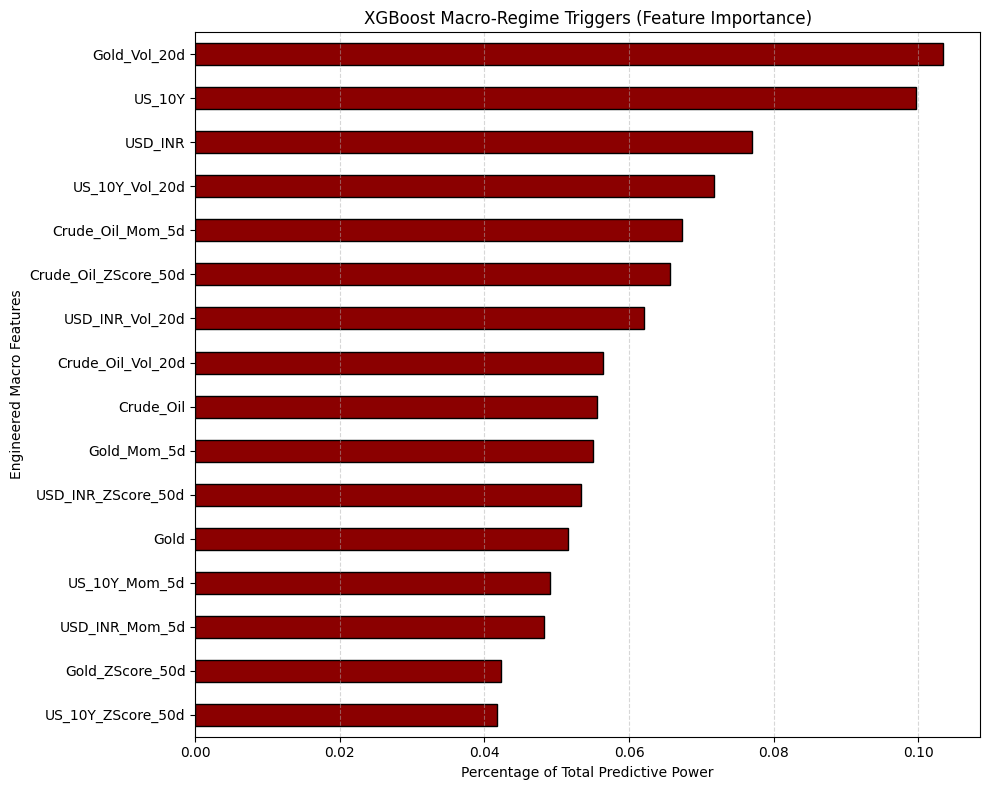

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

print("Retraining on full dataset to extract global alpha...")

# 1. Retrain the model on the full X and y
xgb_model.fit(X, y)

# 2. Extract the mathematically calculated Feature Importances (Gain)
importances = xgb_model.feature_importances_

# 3. Bind the scores to the column names and sort them
feature_names = X.columns
importance_series = pd.Series(importances, index=feature_names)
importance_series = importance_series.sort_values(ascending=True)

# 4. Visualize the Brain of the Model
plt.figure(figsize=(10, 8))
importance_series.plot(kind='barh', color='darkred', edgecolor='black')

plt.title("XGBoost Macro-Regime Triggers (Feature Importance)")
plt.xlabel("Percentage of Total Predictive Power")
plt.ylabel("Engineered Macro Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()